### Data loading

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_CSV = "./train_data/train_data.csv"
TRAIN_IMGS_DIR = "./train_data/images/"
TEST_CSV = "./test_data/test_data.csv"
TEST_IMGS_DIR = "./test_data/images/"
OUTPUT_CSV = "submission.csv"

train_df = pd.read_csv(TRAIN_CSV)

# #Get images in training dataset
# for _, row in train_df.iterrows():
#     img_path = os.path.join(TRAIN_IMGS_DIR, row['image'])
#     img = cv2.imread(img_path)

In [2]:
def get_img(img_file, split='train'):
    path = os.path.join(TRAIN_IMGS_DIR if split=='train' else TEST_IMGS_DIR, img_file)
    img = Image.open(path)
    return img

def plot_img(img_file, split='train'):
    plt.imshow(get_img(img_file, split))

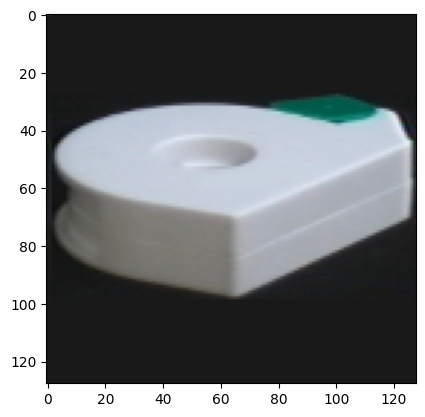

In [3]:
plot_img(train_df['image'][2])

In [4]:
test_df = pd.read_csv(TEST_CSV)
test_df.head(5)

,subtaskID,datapointID,img1,img2,img3
0,1,1,e495bf8d56.png,fbabd3a155.png,e5247843ec.png
1,1,2,2b8c483c63.png,70514a3826.png,1b299e8949.png
2,1,3,7bec1548d4.png,cc858150df.png,410a6b928d.png
3,1,4,e2858adc60.png,5fa9e336c8.png,1ff5c207e0.png
4,1,5,60b7d8c1cd.png,768f294002.png,e32005ac7a.png


In [5]:
task1_test = test_df.dropna()
len(task1_test)

2070

### Annotating with ViT

In [6]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import torch
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vit = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
device = 'cuda'
vit.eval()
vit = vit.to(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [7]:
def vit_pred(entry, print=False):
    img1, img2, img3 = get_img(entry['img1'], 'test'), get_img(entry['img2'], 'test'), get_img(entry['img3'], 'test')
    processed = processor(images=[img1, img2, img3], return_tensors='pt', padding=True)

    with torch.no_grad():
        processed = processed.to(device)
        out = vit.get_image_features(**processed)

    out = out.last_hidden_state[:, 0, :].detach().cpu().numpy()
    sim_mat = cosine_similarity(out, out)
    np.fill_diagonal(sim_mat, 0)
    index = sim_mat.flatten().argmax()
    id1 = index % 3
    id2 = index // 3

    if print:
        fig, ax = plt.subplots(nrows=1, ncols=3)
        ax = ax.flatten()
        ax[0].imshow(img1)
        if 0 in [id1, id2]:
            ax[0].set_xlabel('match', color='green', fontsize=14)
        ax[1].imshow(img2)
        if 1 in [id1, id2]:
            ax[1].set_xlabel('match', color='green', fontsize=14)
        ax[2].imshow(img3)
        if 2 in [id1, id2]:
            ax[2].set_xlabel('match', color='green', fontsize=14)

    ids = [0,1,2]
    ids.remove(id1)
    ids.remove(id2)
    return ids[0]

for i in range(20):
    vit_pred(task1_test.iloc[i])

In [8]:
task1_test_labels = [vit_pred(task1_test.iloc[i]) for i in range(0, len(task1_test))]
task1_test_labels

[2,
 1,
 1,
 2,
 0,
 0,
 0,
 2,
 2,
 0,
 0,
 0,
 2,
 1,
 2,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 2,
 1,
 1,
 2,
 1,
 2,
 2,
 1,
 1,
 2,
 0,
 2,
 1,
 1,
 0,
 0,
 0,
 0,
 2,
 0,
 1,
 2,
 1,
 2,
 1,
 1,
 0,
 0,
 2,
 0,
 2,
 2,
 1,
 1,
 0,
 2,
 1,
 0,
 0,
 0,
 0,
 2,
 1,
 2,
 2,
 1,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 2,
 1,
 0,
 2,
 1,
 1,
 2,
 0,
 2,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 2,
 2,
 1,
 2,
 1,
 0,
 0,
 1,
 0,
 2,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 2,
 0,
 1,
 1,
 2,
 0,
 1,
 1,
 0,
 0,
 1,
 2,
 1,
 0,
 1,
 2,
 2,
 1,
 0,
 0,
 2,
 2,
 2,
 1,
 0,
 0,
 2,
 2,
 0,
 1,
 0,
 1,
 0,
 2,
 2,
 0,
 0,
 2,
 0,
 0,
 2,
 1,
 0,
 1,
 0,
 2,
 0,
 2,
 1,
 2,
 1,
 0,
 0,
 2,
 1,
 1,
 1,
 0,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 0,
 2,
 2,
 0,
 1,
 0,
 1,
 0,
 2,
 1,
 0,
 0,
 1,
 2,
 2,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 2,
 2,
 1,
 2,
 2,
 1,
 1,
 1,
 0,
 2,
 0,
 0,
 0,
 2,
 1,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 1,
 2,
 2,
 0,
 2,
 0,
 1,
 1,
 2,
 2,
 2,
 0,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 2,
 1,


In [9]:
entry = task1_test.iloc[0]

def image_distance(img1, img2):
    return np.mean(np.abs(img1 - img2))

def pred_alg(entry):
    img1 = np.array(get_img(entry['img1'], 'test').convert("RGB")).astype(np.float32)
    img2 = np.array(get_img(entry['img2'], 'test').convert("RGB")).astype(np.float32)
    img3 = np.array(get_img(entry['img3'], 'test').convert("RGB")).astype(np.float32)

    dists = [image_distance(img2, img3), image_distance(img1, img3), image_distance(img1, img2)]
    return np.argmin(dists)

task1_test_preds = [pred_alg(task1_test.iloc[i]) for i in range(0, len(task1_test))]
task1_test_preds

[np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.in

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(task1_test_labels, task1_test_preds)

0.8777777777777778

In [11]:
from sklearn.model_selection import train_test_split
y = train_df['angle']/360
x = train_df.drop('angle', axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05)
len(x_train), len(x_test), y_train[0]

(1900, 100, np.float64(0.625))

In [12]:
from torchvision.models import efficientnet_b0, resnet18
from torch import nn
model = efficientnet_b0()
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=1, bias=True)
)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ImageRegressionDataset(Dataset):
    def __init__(self, imgs, labels):
        self.imgs = imgs
        self.labels = labels

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(TRAIN_IMGS_DIR, self.imgs[idx])
        image = Image.open(img_path).convert("RGB")

        target = torch.tensor([self.labels[idx]], dtype=torch.float32)
        return image, target


# # ----------------------------
# # Model (ResNet backbone)
# # ----------------------------
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = resnet18()

        # replace final layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.backbone(x)


# ----------------------------
# Train function
# ----------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


# ----------------------------
# Validation function
# ----------------------------
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)
        loss = criterion(preds, targets)

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


train_dataset = ImageRegressionDataset(x_train, y_train)
val_dataset = ImageRegressionDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# model = RegressionModel().to(device)
model = efficientnet_b0()
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=1, bias=True)
)

# loss + optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

best_val_loss = float("inf")

# training loop
epochs = 10

print("start")

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best model!")

start
